
Preprocessing

Trim black borders occuring in several images in the ISIC training and test datasets. We use a very small fuzz factor to remove contigous black borders while retaining important parts of the image. Execute only once. This will take some time. Moved preprocessed images to directory isic_preproc.


In [35]:
%cd
%cd dev1/scaling-laws-ecnn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
#from IPython.display import Image
import numpy as np

from training.datasets.utils import get_normalize_weights
# reload
%load_ext autoreload
%autoreload 2

/home/frischs
/home/frischs/dev1/scaling-laws-ecnn
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
ROOT_DIR = '../../Data/frischs/datasets/'
isic_path = ROOT_DIR + 'ISIC_2019/ISIC_2019_Training_Input'
def get_isic_df():
    df = pd.read_csv(ROOT_DIR + 'ISIC_2019/ISIC_2019_Training_GroundTruth.csv')
    path_img = 'ISIC_2019_Training_Input'
    
    df.columns[1:]

    for label in df.columns[1:]:
        df.loc[df[label] == 1.0, 'label'] = label
        
    df.rename(columns={'image': 'name'}, inplace=True)
    df['name'] = df['name'].apply(lambda x: "{}/{}.jpg".format(isic_path,x))
    df = df[['name', 'label']]
    return df

data=get_isic_df()


In [4]:
labels, images = data.groupby('label').first()["name"].keys().tolist(), data.groupby('label').first()["name"].values.tolist()
# rowiter

In [42]:
#data["images"]
data["images"].apply(lambda x: x.shape).value_counts()

# Create a function to calculate the absolute difference between height and width
def get_abs_diff(shape):
    return abs(shape[0] - shape[1])

# Calculate the absolute differences for each image and add it as a new column
data['abs_diff'] = data['images'].apply(lambda x: get_abs_diff(x.shape))

# Sort the DataFrame by the absolute difference in descending order
sorted_data = data.sort_values(by='abs_diff', ascending=False)

# Select the top 5 images with the largest absolute differences
top_5_images = sorted_data.head(5)
top_5_images

,name,label,images,abs_diff
170,../../Data/frischs/datasets/ISIC_2019/ISIC_201...,5,"[[[252, 247, 244], [220, 212, 210], [249, 239,...",355
2428,../../Data/frischs/datasets/ISIC_2019/ISIC_201...,2,"[[[180, 160, 159], [173, 158, 155], [169, 155,...",353
181,../../Data/frischs/datasets/ISIC_2019/ISIC_201...,5,"[[[244, 253, 252], [219, 223, 224], [240, 238,...",352
2741,../../Data/frischs/datasets/ISIC_2019/ISIC_201...,5,"[[[210, 136, 135], [215, 139, 141], [220, 141,...",351
166,../../Data/frischs/datasets/ISIC_2019/ISIC_201...,5,"[[[240, 253, 244], [205, 215, 206], [242, 241,...",351


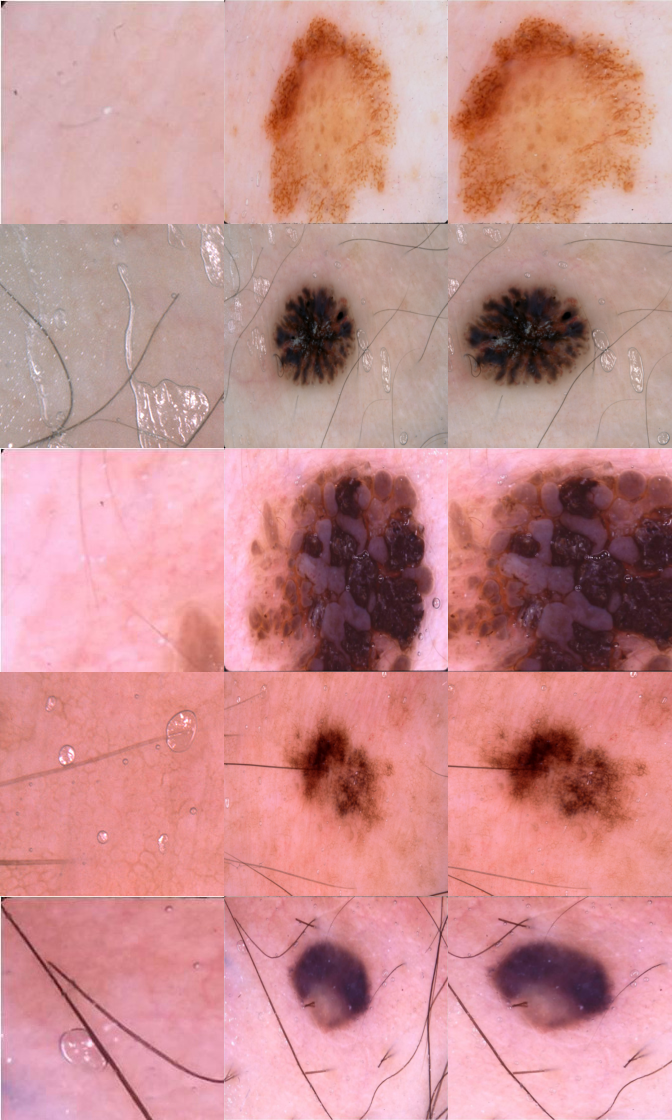

In [52]:
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms.functional as F

def create_combined_image(image_paths, labels, resolution):
    # Calculate the total height of the combined image
    combined_height = resolution * len(image_paths)
    
    # Create a blank canvas for the combined image
    combined_image = Image.new('RGB', (resolution * 3, combined_height))

    # Loop through the image paths and labels
    for i, (image_path, label) in enumerate(zip(image_paths, labels)):
        # Open the original image
        img_original = Image.open(image_path)
        
        # Resize the image
        img_resized = F.resize(img_original, (resolution, resolution))

        # Calculate the shorter side
        shorter_side = min(img_original.size)
        
        # Center crop to the shorter side and resize
        img_center_cropped = F.center_crop(img_original, shorter_side)
        img_center_resized = F.resize(img_center_cropped, (resolution, resolution))

        # Calculate the position to paste this example in the combined image
        y_position = i * resolution
        
        # Paste the images into the combined image
        combined_image.paste(img_original, (0, y_position))
        combined_image.paste(img_resized, (resolution, y_position))
        combined_image.paste(img_center_resized, (resolution * 2, y_position))

    return combined_image


create_combined_image(top_5_images["name"], top_5_images["label"], 224)


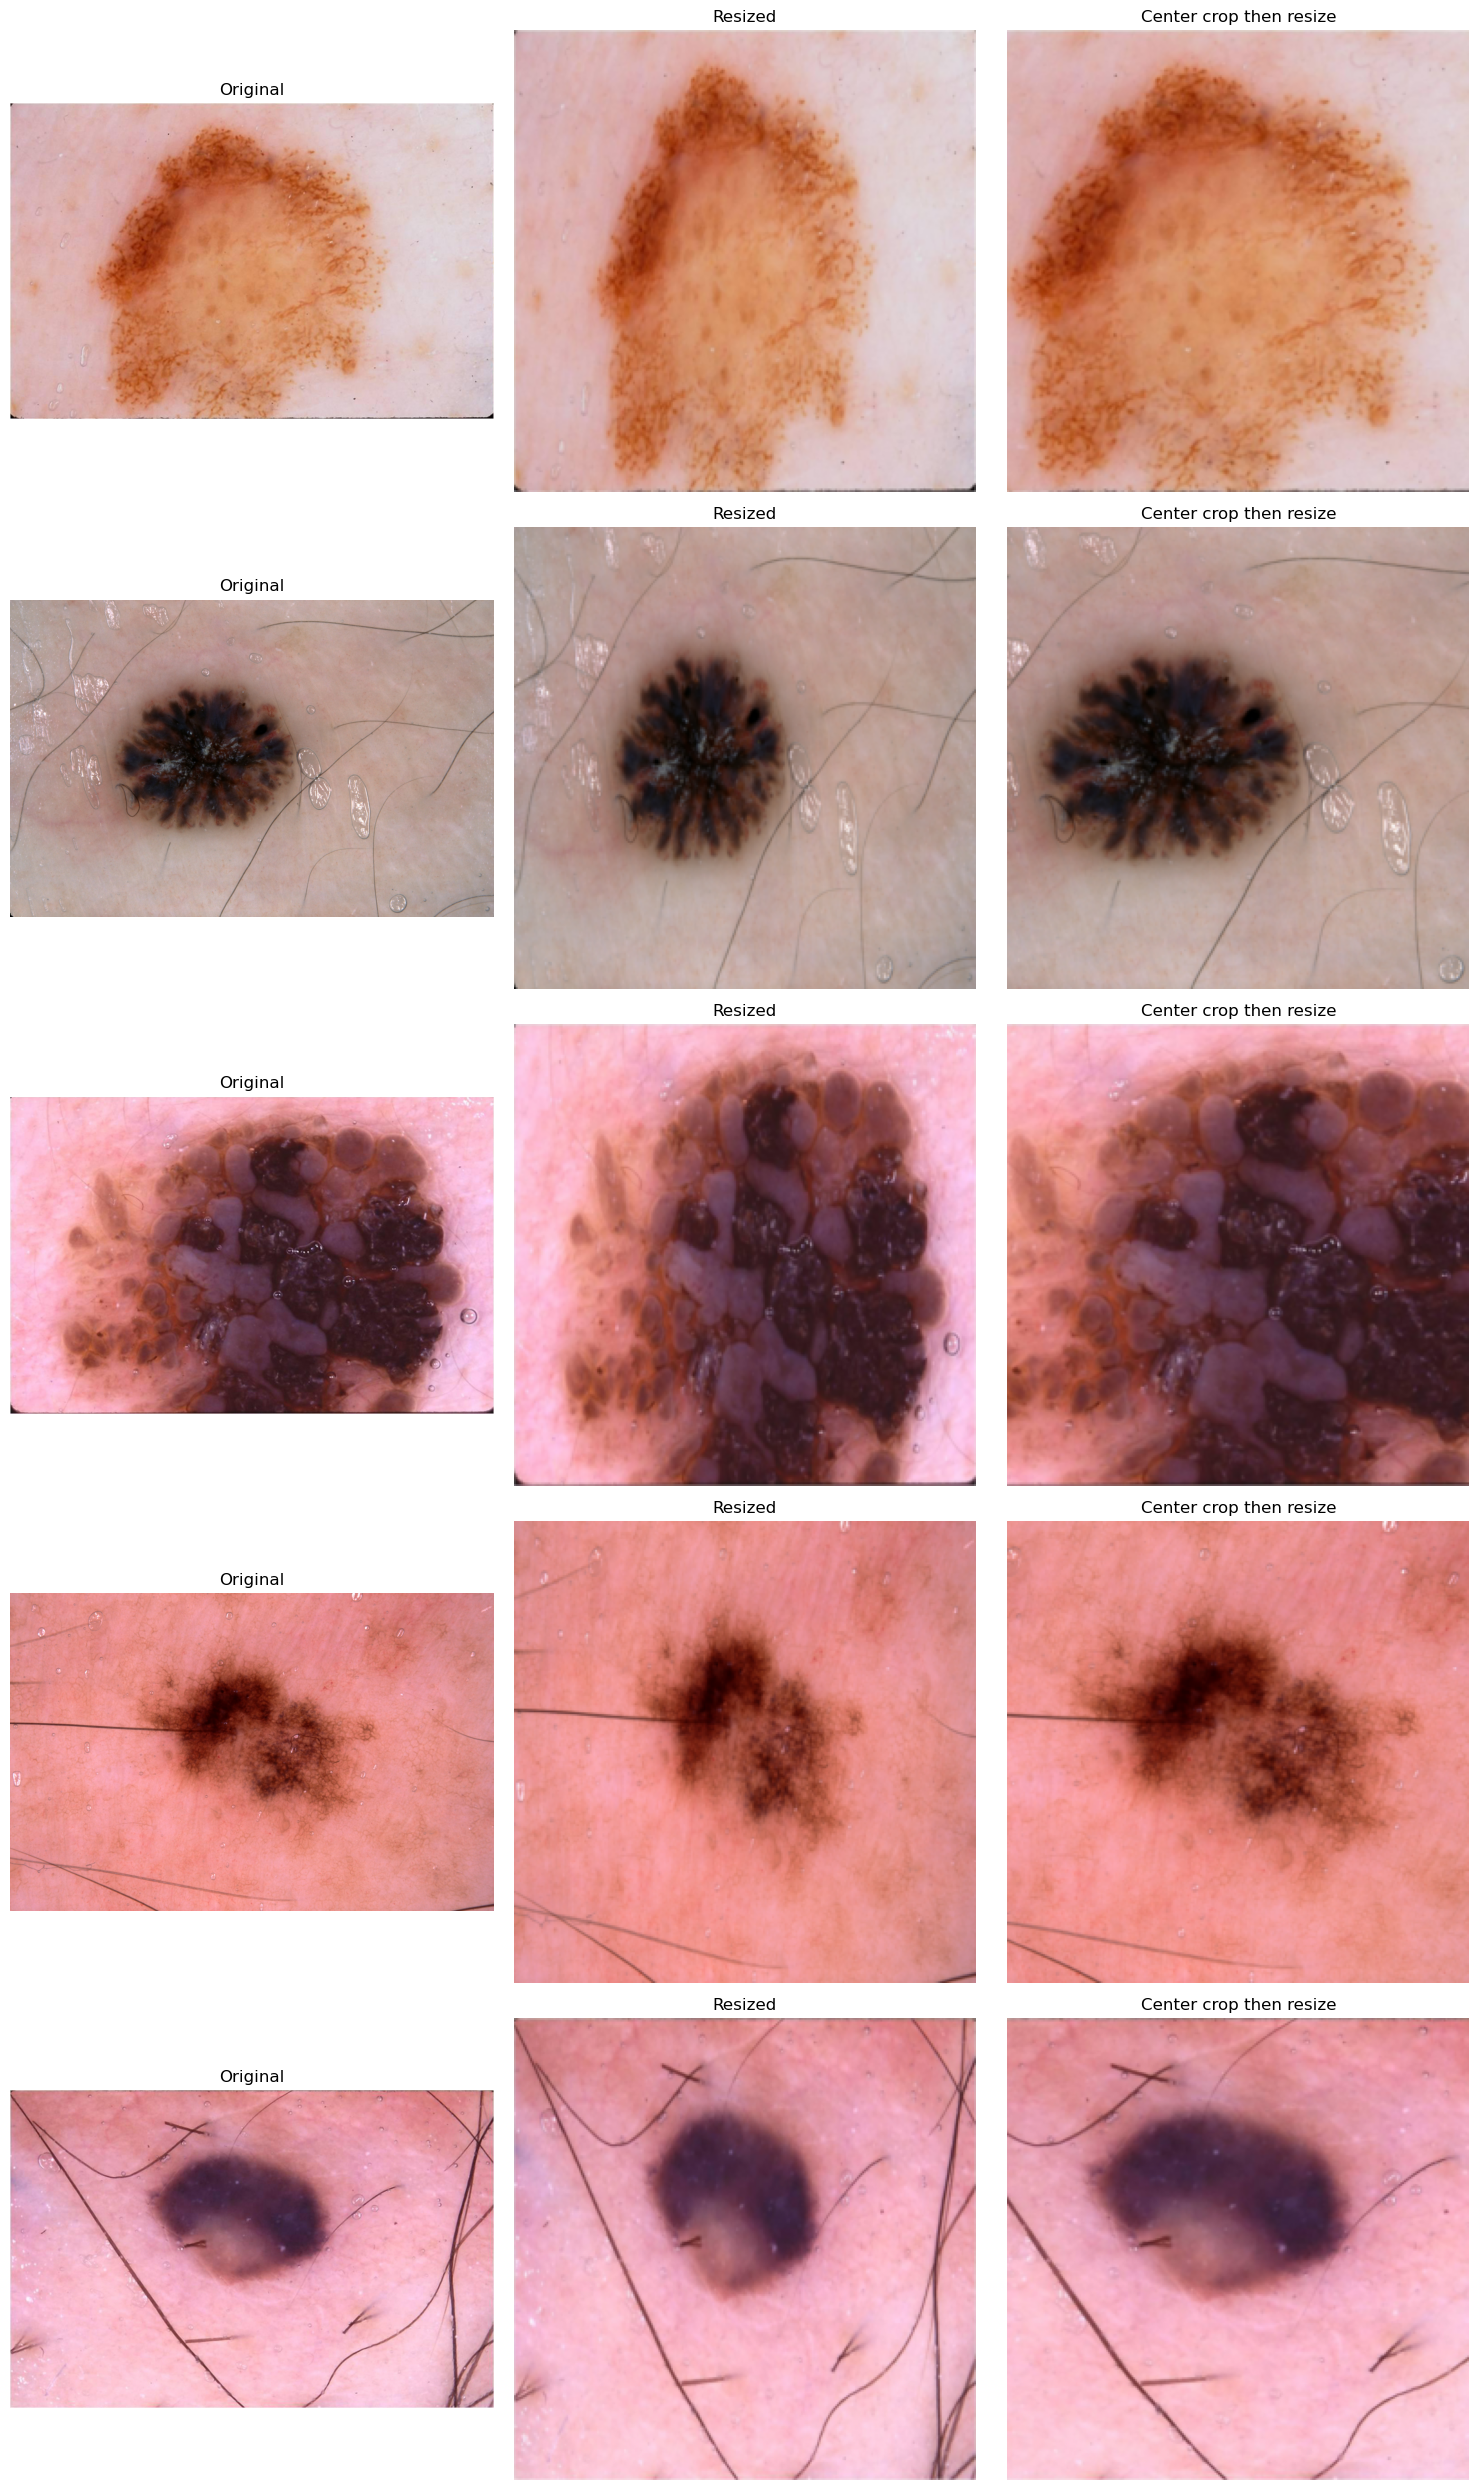

In [56]:
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms.functional as F

def show_original_and_resized_images(image_paths, resolution):
    num_images = len(image_paths)

    # Create subplots with multiple rows
    fig, axs = plt.subplots(num_images, 3, figsize=(15, 5*num_images))

    for i, image_path in enumerate(image_paths):
        # Open the original image
        img_original = Image.open(image_path)

        # Resize the image
        img_resized = F.resize(img_original, (resolution, resolution))

        # Calculate the shorter side
        shorter_side = min(img_original.size)

        # Center crop to the shorter side and resize
        img_center_cropped = F.center_crop(img_original, shorter_side)
        img_center_resized = F.resize(img_center_cropped, (resolution, resolution))

        # Plot the original image on the left
        axs[i, 0].imshow(img_original)
        axs[i, 0].set_title(f'Original')
        axs[i, 0].axis('off')

        # Plot the resized image in the middle
        axs[i, 1].imshow(img_resized)
        axs[i, 1].set_title(f'Resized')
        axs[i, 1].axis('off')

        # Plot the center-cropped image on the right
        axs[i, 2].imshow(img_center_resized)
        axs[i, 2].set_title(f'Center crop then resize')
        axs[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# Set the desired resolution for resizing
resolution = 256  # Change this to your desired resolution

# Display the original and resized images for the first 5 images
show_original_and_resized_images(top_5_images["name"], resolution)


5


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

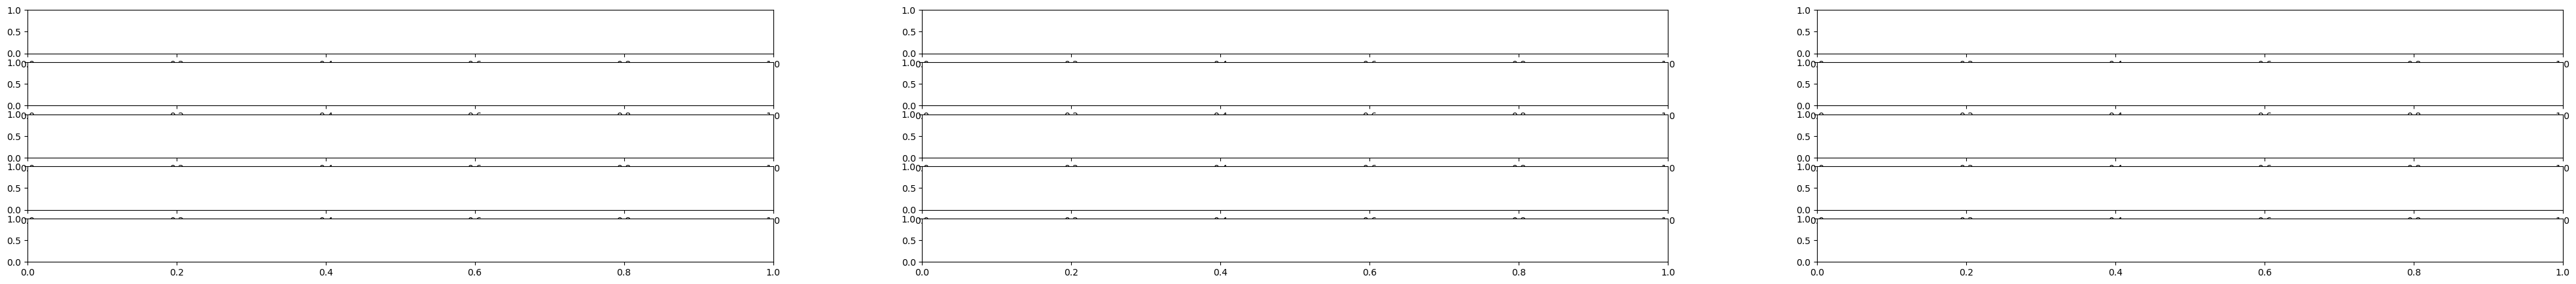

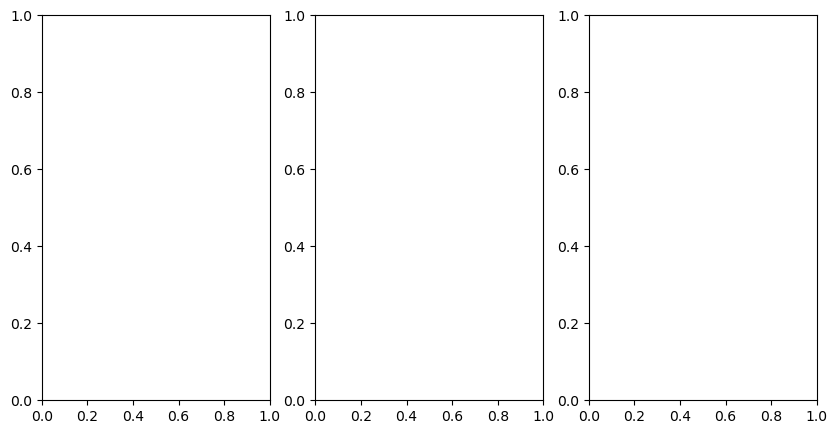

In [55]:
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms.functional as f

def show_original_and_resized_images(image_paths, resolution):
    len(image_paths)
    print(len(image_paths))
    fig, axs = plt.subplots(len(image_paths), 3, figsize=(10*len(image_paths), 5))

    for i, image_path in enumerate(image_paths):
        # Open the original image
        img_original = Image.open(image_path)

        # Resize the image
        img_resized = f.resize(img_original, (resolution, resolution))
        #img_resized = img_original.resize((resolution, resolution))

        # center crop to short side then resize to resolution
        shorter_side = min(img_original.size)
        img_center_resized = f.center_crop(img_original, shorter_side)
        img_center_resized = f.resize(img_center_resized, (resolution, resolution))


        # Create subplots for the original and resized images
        fig, axs = plt.subplots(1, 3, figsize=(10, 5))

        # Plot the original image on the left
        axs[i, 0].imshow(img_original)
        axs[i, 0].set_title(f'Original')
        axs[i, 0].axis('off')

        # Plot the resized image on the right
        axs[i, 1].imshow(img_resized)
        axs[i, 1].set_title(f'Resized')
        axs[i, 1].axis('off')

        # Plot the resized image on the right
        axs[i, 2].imshow(img_center_resized)
        axs[i, 2].set_title(f'Center crop then resize')
        axs[i, 2].axis('off')

        plt.show()


# Set the desired resolution for resizing
resolution = 256  # Change this to your desired resolution

# Display the original and resized images for the first 5 images

show_original_and_resized_images(top_5_images["name"], 224)


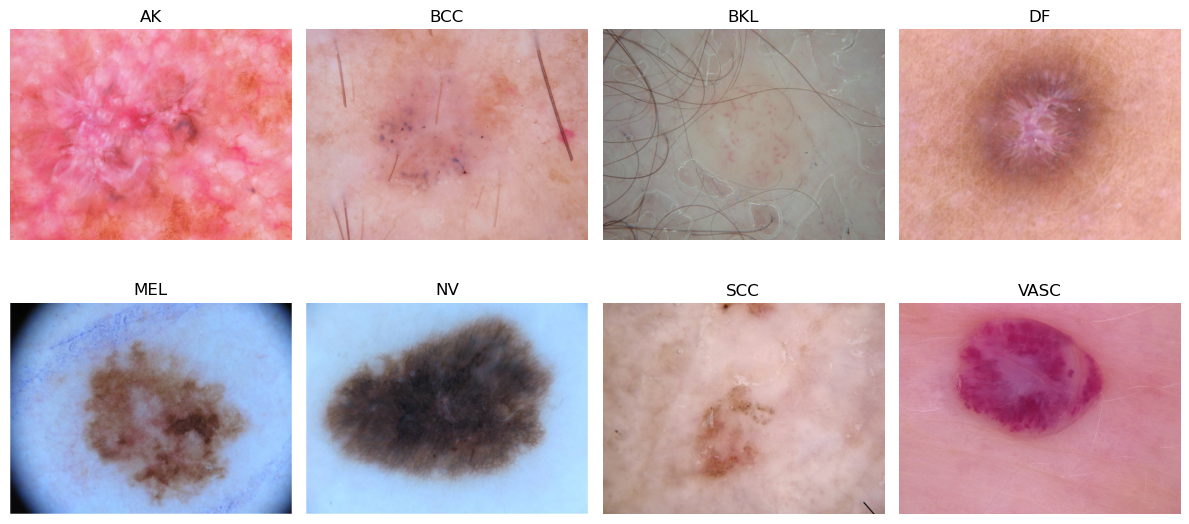

In [36]:
# get one image from each class
labels, image_paths = data.groupby('label').first()["name"].keys().tolist(), data.groupby('label').first()["name"].values.tolist()

def show_image(image_path, label):
    img = Image.open(image_path)
    plt.subplot(2, 4, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

plt.figure(figsize=(12, 6))

for i, (path, label) in enumerate(zip(image_paths, labels)):
    show_image(path, label)
plt.tight_layout()
plt.show()

# transforms.Resize((resolution, resolution))


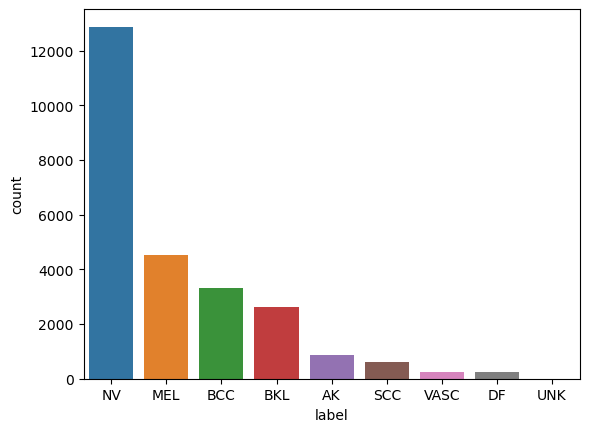

In [5]:
ax = sns.countplot(x="label", data=get_isic_df(), order=['NV', 'MEL', 'BCC', 'BKL', 'AK', 'SCC', 'VASC', 'DF','UNK'])

In [6]:
data['label'].unique()
for c in data['label'].unique():
    print(c, len(data[data['label'] == c]))

NV 12875
MEL 4522
BKL 2624
DF 239
SCC 628
BCC 3323
VASC 253
AK 867


In [30]:
df = get_isic_df()
df['label'] = lab.fit_transform(df['label'])
df['label'].value_counts() / df['label'].value_counts().sum()

5    0.508270
4    0.178516
1    0.131183
2    0.103588
0    0.034227
6    0.024792
7    0.009988
3    0.009435
Name: label, dtype: float64

In [36]:
data["images"] = data["name"].apply(lambda x: np.array(Image.open(x)))

In [37]:
data["images"].values

array([array([[[251, 255, 255],
               [232, 241, 248],
               [243, 255, 255],
               ...,
               [237, 255, 255],
               [238, 250, 255],
               [255, 255, 255]],

              [[230, 234, 243],
               [175, 183, 194],
               [165, 181, 197],
               ...,
               [177, 203, 230],
               [184, 200, 216],
               [243, 246, 251]],

              [[245, 251, 255],
               [171, 179, 198],
               [147, 163, 186],
               ...,
               [156, 189, 222],
               [169, 190, 211],
               [243, 253, 255]],

              ...,

              [[238, 255, 255],
               [178, 196, 234],
               [169, 188, 231],
               ...,
               [186, 220, 245],
               [194, 217, 235],
               [242, 254, 255]],

              [[232, 244, 255],
               [183, 195, 211],
               [182, 194, 216],
               ...,
        

In [8]:
image_path = data.head(10).iloc[2]['name']
#Image(image_path)
# Load the image using Pillow
image_pil = Image.open(image_path)

# Convert the image to a NumPy array
image_np = np.array(image_pil)

#mean = np.mean(images, axis=(0, 1, 2))
#std = np.std(images, axis=(0, 1, 2))

In [38]:
#data["images"].to_numpy()# .mean(axis=(0, 1, 2))

data["images"].apply(lambda x: x.shape).value_counts()


(1024, 1024, 3)    12414
(450, 600, 3)      10015
(680, 1024, 3)      1121
(768, 1024, 3)       774
(682, 1024, 3)       173
                   ...  
(723, 959, 3)          1
(672, 964, 3)          1
(723, 957, 3)          1
(640, 957, 3)          1
(676, 962, 3)          1
Name: images, Length: 101, dtype: int64

In [39]:
shapes = data["images"].apply(lambda x: x.shape).tolist()

# Initialize variables to store the minimum height and width
min_height = float('inf')
min_width = float('inf')

# Iterate through the shape tuples to find the minimum values
for shape in shapes:
    height, width, _ = shape  # Assuming the third dimension is always 3
    min_height = min(min_height, height)
    min_width = min(min_width, width)

print("Minimum height:", min_height)
print("Minimum width:", min_width)

Minimum height: 450
Minimum width: 576


In [23]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
import pandas as pd
from PIL import Image

class ISICDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image = Image.open(self.dataframe.iloc[idx, 0])
        label = self.dataframe.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        return image, label

def get_isic_loaders():
    # Load the dataframe
    df = get_isic_df()

    # Split the data
    train_df, val_test_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['label'])
    test_df, val_df = train_test_split(val_test_df, test_size=0.5, random_state=42, stratify=val_test_df['label'])

    # Define the transformations
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        #transforms.Normalize(mean=[0.6679, 0.5299, 0.5245], std=[0.1332, 0.1475, 0.1588]),
    ])

    # Create the DataLoaders
    train_loader = DataLoader(ISICDataset(train_df, transform=transform), batch_size=64, shuffle=True)
    val_loader = DataLoader(ISICDataset(val_df, transform=transform), batch_size=64, shuffle=False)
    test_loader = DataLoader(ISICDataset(test_df, transform=transform), batch_size=64, shuffle=False)

    return train_loader, val_loader, test_loader


In [25]:
import numpy as np

def compute_img_stats(loader):
    mean = 0.
    std = 0.
    nb_samples = 0.
    
    for data, _ in loader:
        batch_samples = data.size(0)
        data = data.view(batch_samples, data.size(1), -1)
        mean += data.mean(2).sum(0)
        std += data.std(2).sum(0)
        nb_samples += batch_samples

    mean /= nb_samples
    std /= nb_samples

    return mean, std

def get_stats(df):
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
    ])
    loader = DataLoader(ISICDataset(df, transform=transform), batch_size=1024, shuffle=False)
    return compute_img_stats(loader)

# Load the dataframe
df = get_isic_df()

# Compute the statistics
mean, std = get_stats(df)

print('Mean:', mean)
print('Std:', std)

# Mean: tensor([0.6679, 0.5299, 0.5245])
# Std: tensor([0.1332, 0.1475, 0.1588])

Mean: tensor([0.6679, 0.5299, 0.5245])
Std: tensor([0.1332, 0.1475, 0.1588])
